# Breast Cancer Wisconsin (Diagnostic) - ML Classification Project

This notebook follows the same steps used in the course notebooks (Pima Indians dataset), applied here to the **Breast Cancer Wisconsin (Diagnostic)** dataset (WDBC).

Steps covered:
1. Load the dataset
2. Explore the data (descriptive statistics)
3. Explore the data (visualizations)
4. Train/test split and feature scaling
5. Feature selection
6. Evaluate performance with resampling
7. Compare and tune ML algorithms (with full performance metrics)
8. Summary of results

## 1. Loading the Dataset

### Where the dataset comes from

The Breast Cancer dataset is a classic binary classification dataset. Features are computed from a digitized image of a fine needle aspirate of a breast mass, and describe characteristics of the cell nucleus present in the image.

Source: UCI Machine Learning Repository - https://archive.ics.uci.edu/dataset/17/breast+cancer+wisconsin+diagnostic

* Number of instances: 569
* Number of attributes: 30 numeric input features + 1 ID + 1 target
* Target variable: diagnosis (M = malignant, B = benign)
* Missing values: none

### Description of the dataset

Each row corresponds to one fine needle aspirate image, and each of the 10 underlying cell-nucleus properties listed below was turned into 3 columns: its mean value, its standard error, and its worst value (the average of the three largest measurements found in that image). That is where the 30 numeric features (columns 3-32 of the raw file) come from. Column 1 is just a record ID, and column 2 holds the diagnosis label that we want to predict.

The 10 base properties, computed per cell nucleus:

1. **Radius** - average distance from the nucleus center to its perimeter
2. **Texture** - variability (std. dev.) of the gray-scale pixel values
3. **Perimeter**
4. **Area**
5. **Smoothness** - how much the radius changes locally along the perimeter
6. **Compactness** - derived from `perimeter^2 / area - 1.0`
7. **Concavity** - how deep/severe the concave (inward-curving) parts of the contour are
8. **Concave points** - how many concave sections the contour has
9. **Symmetry**
10. **Fractal dimension** - roughly, how "rough" or complex the contour boundary is

### Get the dataset

I loaded the raw WDBC file directly with pandas. This avoids `wget` (which is not available in some Jupyter environments) and also avoids requiring the `ucimlrepo` package which was suggested in the dataset owners' website.

The raw UCI file contains an ID column, the diagnosis (`M`/`B`), and 30 numeric features. I removed the ID and arranged the columns so that the rest of this notebook can keep using `diagnosis` as column 0 and the 30 features as columns 1-30.

In [29]:
import pandas as pd

feature_names = [
    'radius_mean', 'texture_mean', 'perimeter_mean', 'area_mean', 'smoothness_mean',
    'compactness_mean', 'concavity_mean', 'concave_points_mean', 'symmetry_mean',
    'fractal_dimension_mean',
    'radius_se', 'texture_se', 'perimeter_se', 'area_se', 'smoothness_se',
    'compactness_se', 'concavity_se', 'concave_points_se', 'symmetry_se',
    'fractal_dimension_se',
    'radius_worst', 'texture_worst', 'perimeter_worst', 'area_worst',
    'smoothness_worst', 'compactness_worst', 'concavity_worst',
    'concave_points_worst', 'symmetry_worst', 'fractal_dimension_worst'
]

raw_columns = ['id', 'diagnosis'] + feature_names

# Loading the locally uploaded dataset file
raw = pd.read_csv(
    "wdbc.data",
    header=None,
    names=raw_columns
)

# Removing the ID column
data = raw[['diagnosis'] + feature_names].copy()

# Encoding diagnosis: M = 1, B = 0
data['diagnosis'] = data['diagnosis'].map({'M': 1, 'B': 0})

print("Dataset shape:", data.shape)
data.head()

Dataset shape: (569, 31)


,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave_points_mean,symmetry_mean,fractal_dimension_mean,radius_se,texture_se,perimeter_se,area_se,smoothness_se,compactness_se,concavity_se,concave_points_se,symmetry_se,fractal_dimension_se,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave_points_worst,symmetry_worst,fractal_dimension_worst
0,1,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,1.0950,0.9053,8.589,153.40,0.006399,0.04904,0.05373,0.01587,0.03003,0.006193,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,0.5435,0.7339,3.398,74.08,0.005225,0.01308,0.01860,0.01340,0.01389,0.003532,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,1,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,0.7456,0.7869,4.585,94.03,0.006150,0.04006,0.03832,0.02058,0.02250,0.004571,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,1,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,0.4956,1.1560,3.445,27.23,0.009110,0.07458,0.05661,0.01867,0.05963,0.009208,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,1,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,0.7572,0.7813,5.438,94.44,0.011490,0.02461,0.05688,0.01885,0.01756,0.005115,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [3]:
# See basic dataset information
print("Rows:", data.shape[0])
print("Features:", len(feature_names))
print("Diagnosis values:", data['diagnosis'].unique())

Rows: 569
Features: 30
Diagnosis values: [1 0]


In [4]:
# Variable information
print(data.dtypes)

diagnosis                    int64
radius_mean                float64
texture_mean               float64
perimeter_mean             float64
area_mean                  float64
smoothness_mean            float64
compactness_mean           float64
concavity_mean             float64
concave_points_mean        float64
symmetry_mean              float64
fractal_dimension_mean     float64
radius_se                  float64
texture_se                 float64
perimeter_se               float64
area_se                    float64
smoothness_se              float64
compactness_se             float64
concavity_se               float64
concave_points_se          float64
symmetry_se                float64
fractal_dimension_se       float64
radius_worst               float64
texture_worst              float64
perimeter_worst            float64
area_worst                 float64
smoothness_worst           float64
compactness_worst          float64
concavity_worst            float64
concave_points_worst

## 2. Exploring the data with descriptive statistics

### Dimensions

In [5]:
shape = data.shape
shape

(569, 31)

### Data types

In [6]:
types = data.dtypes
print(types)

diagnosis                    int64
radius_mean                float64
texture_mean               float64
perimeter_mean             float64
area_mean                  float64
smoothness_mean            float64
compactness_mean           float64
concavity_mean             float64
concave_points_mean        float64
symmetry_mean              float64
fractal_dimension_mean     float64
radius_se                  float64
texture_se                 float64
perimeter_se               float64
area_se                    float64
smoothness_se              float64
compactness_se             float64
concavity_se               float64
concave_points_se          float64
symmetry_se                float64
fractal_dimension_se       float64
radius_worst               float64
texture_worst              float64
perimeter_worst            float64
area_worst                 float64
smoothness_worst           float64
compactness_worst          float64
concavity_worst            float64
concave_points_worst

### Descriptive statistics

In [30]:
from pandas import set_option

set_option('display.width', 200)
set_option('display.max_rows', 500)
set_option('display.max_columns', 500)

description = data.describe()
print(description)

        diagnosis  radius_mean  texture_mean  perimeter_mean    area_mean  smoothness_mean  compactness_mean  concavity_mean  concave_points_mean  symmetry_mean  fractal_dimension_mean   radius_se  \
count  569.000000   569.000000    569.000000      569.000000   569.000000       569.000000        569.000000      569.000000           569.000000     569.000000              569.000000  569.000000   
mean     0.372583    14.127292     19.289649       91.969033   654.889104         0.096360          0.104341        0.088799             0.048919       0.181162                0.062798    0.405172   
std      0.483918     3.524049      4.301036       24.298981   351.914129         0.014064          0.052813        0.079720             0.038803       0.027414                0.007060    0.277313   
min      0.000000     6.981000      9.710000       43.790000   143.500000         0.052630          0.019380        0.000000             0.000000       0.106000                0.049960    0.111500   


There is no missing data as implicated in the data source as well.
By looking at the overall structure, it is clear that I need to perform scaling to have a non-biased analysis.

### Class distribution

diagnosis
0    357
1    212
dtype: int64


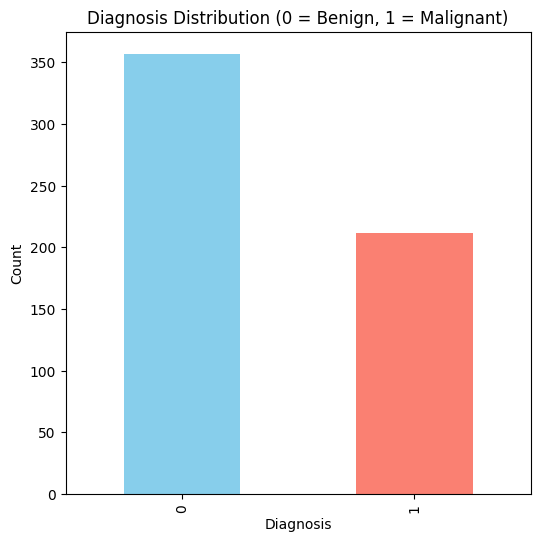

In [31]:
class_counts = data.groupby('diagnosis').size()
print(class_counts)

from matplotlib import pyplot

pyplot.figure(figsize=(6, 6))
ax = class_counts.plot(kind='bar', color=['skyblue', 'salmon'])
pyplot.title('Diagnosis Distribution (0 = Benign, 1 = Malignant)')
pyplot.xlabel('Diagnosis')
pyplot.ylabel('Count')
pyplot.show()

### Correlations between attributes

In [32]:
set_option('display.width', 100)

correlations = data.corr(method='pearson')
correlations

,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave_points_mean,symmetry_mean,fractal_dimension_mean,radius_se,texture_se,perimeter_se,area_se,smoothness_se,compactness_se,concavity_se,concave_points_se,symmetry_se,fractal_dimension_se,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave_points_worst,symmetry_worst,fractal_dimension_worst
diagnosis,1.000000,0.730029,0.415185,0.742636,0.708984,0.358560,0.596534,0.696360,0.776614,0.330499,-0.012838,0.567134,-0.008303,0.556141,0.548236,-0.067016,0.292999,0.253730,0.408042,-0.006522,0.077972,0.776454,0.456903,0.782914,0.733825,0.421465,0.590998,0.659610,0.793566,0.416294,0.323872
radius_mean,0.730029,1.000000,0.323782,0.997855,0.987357,0.170581,0.506124,0.676764,0.822529,0.147741,-0.311631,0.679090,-0.097317,0.674172,0.735864,-0.222600,0.206000,0.194204,0.376169,-0.104321,-0.042641,0.969539,0.297008,0.965137,0.941082,0.119616,0.413463,0.526911,0.744214,0.163953,0.007066
texture_mean,0.415185,0.323782,1.000000,0.329533,0.321086,-0.023389,0.236702,0.302418,0.293464,0.071401,-0.076437,0.275869,0.386358,0.281673,0.259845,0.006614,0.191975,0.143293,0.163851,0.009127,0.054458,0.352573,0.912045,0.358040,0.343546,0.077503,0.277830,0.301025,0.295316,0.105008,0.119205
perimeter_mean,0.742636,0.997855,0.329533,1.000000,0.986507,0.207278,0.556936,0.716136,0.850977,0.183027,-0.261477,0.691765,-0.086761,0.693135,0.744983,-0.202694,0.250744,0.228082,0.407217,-0.081629,-0.005523,0.969476,0.303038,0.970387,0.941550,0.150549,0.455774,0.563879,0.771241,0.189115,0.051019
area_mean,0.708984,0.987357,0.321086,0.986507,1.000000,0.177028,0.498502,0.685983,0.823269,0.151293,-0.283110,0.732562,-0.066280,0.726628,0.800086,-0.166777,0.212583,0.207660,0.372320,-0.072497,-0.019887,0.962746,0.287489,0.959120,0.959213,0.123523,0.390410,0.512606,0.722017,0.143570,0.003738
smoothness_mean,0.358560,0.170581,-0.023389,0.207278,0.177028,1.000000,0.659123,0.521984,0.553695,0.557775,0.584792,0.301467,0.068406,0.296092,0.246552,0.332375,0.318943,0.248396,0.380676,0.200774,0.283607,0.213120,0.036072,0.238853,0.206718,0.805324,0.472468,0.434926,0.503053,0.394309,0.499316
compactness_mean,0.596534,0.506124,0.236702,0.556936,0.498502,0.659123,1.000000,0.883121,0.831135,0.602641,0.565369,0.497473,0.046205,0.548905,0.455653,0.135299,0.738722,0.570517,0.642262,0.229977,0.507318,0.535315,0.248133,0.590210,0.509604,0.565541,0.865809,0.816275,0.815573,0.510223,0.687382
concavity_mean,0.696360,0.676764,0.302418,0.716136,0.685983,0.521984,0.883121,1.000000,0.921391,0.500667,0.336783,0.631925,0.076218,0.660391,0.617427,0.098564,0.670279,0.691270,0.683260,0.178009,0.449301,0.688236,0.299879,0.729565,0.675987,0.448822,0.754968,0.884103,0.861323,0.409464,0.514930
concave_points_mean,0.776614,0.822529,0.293464,0.850977,0.823269,0.553695,0.831135,0.921391,1.000000,0.462497,0.166917,0.698050,0.021480,0.710650,0.690299,0.027653,0.490424,0.439167,0.615634,0.095351,0.257584,0.830318,0.292752,0.855923,0.809630,0.452753,0.667454,0.752399,0.910155,0.375744,0.368661
symmetry_mean,0.330499,0.147741,0.071401,0.183027,0.151293,0.557775,0.602641,0.500667,0.462497,1.000000,0.479921,0.303379,0.128053,0.313893,0.223970,0.187321,0.421659,0.342627,0.393298,0.449137,0.331786,0.185728,0.090651,0.219169,0.177193,0.426675,0.473200,0.433721,0.430297,0.699826,0.438413


### Skew of univariate distributions

In [33]:
skew = data.skew()
print(skew)

diagnosis                  0.528461
radius_mean                0.942380
texture_mean               0.650450
perimeter_mean             0.990650
area_mean                  1.645732
smoothness_mean            0.456324
compactness_mean           1.190123
concavity_mean             1.401180
concave_points_mean        1.171180
symmetry_mean              0.725609
fractal_dimension_mean     1.304489
radius_se                  3.088612
texture_se                 1.646444
perimeter_se               3.443615
area_se                    5.447186
smoothness_se              2.314450
compactness_se             1.902221
concavity_se               5.110463
concave_points_se          1.444678
symmetry_se                2.195133
fractal_dimension_se       3.923969
radius_worst               1.103115
texture_worst              0.498321
perimeter_worst            1.128164
area_worst                 1.859373
smoothness_worst           0.415426
compactness_worst          1.473555
concavity_worst            1

Skewness is the measure of how asymmetric the distirbution of the data is:
* skew ~ 0 -> roughly symmetric
* skew > 0 -> positively skewed (right tail is longer)
* skew < 0 -> negatively skewed (left tail is longer)

Some of the columns show a fairly strong positive skew.

## 3. Explore your data with visualization

I will show:

* Univariate plots (Histograms, Density plots, Box and Whisker plots)
* Multivariate plots (Correlation matrix, Scatter matrix)

### Histograms

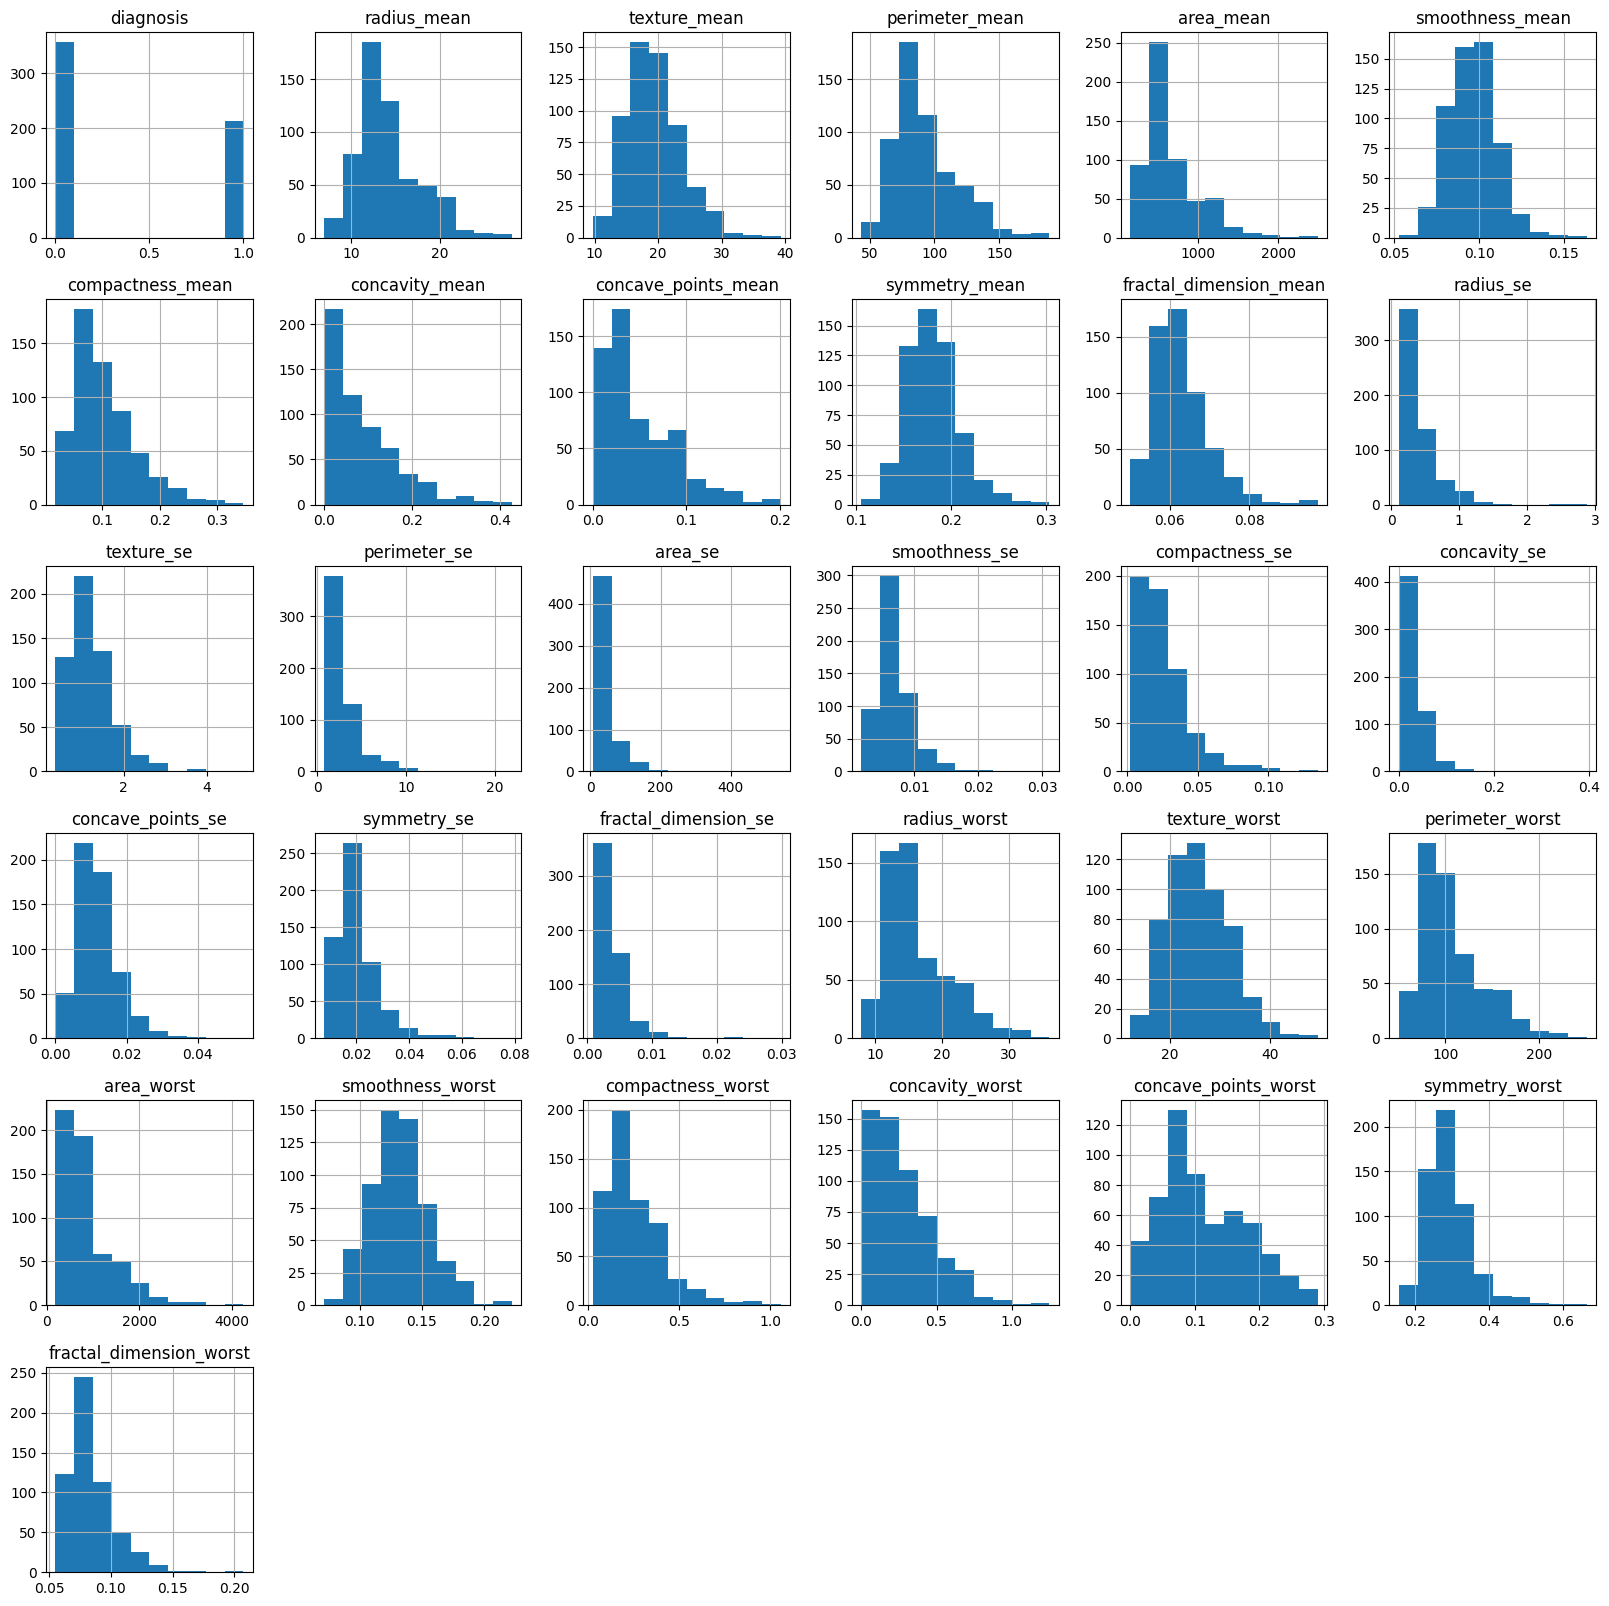

In [34]:
data.hist(figsize=(20, 20))
pyplot.show()

### Density plots

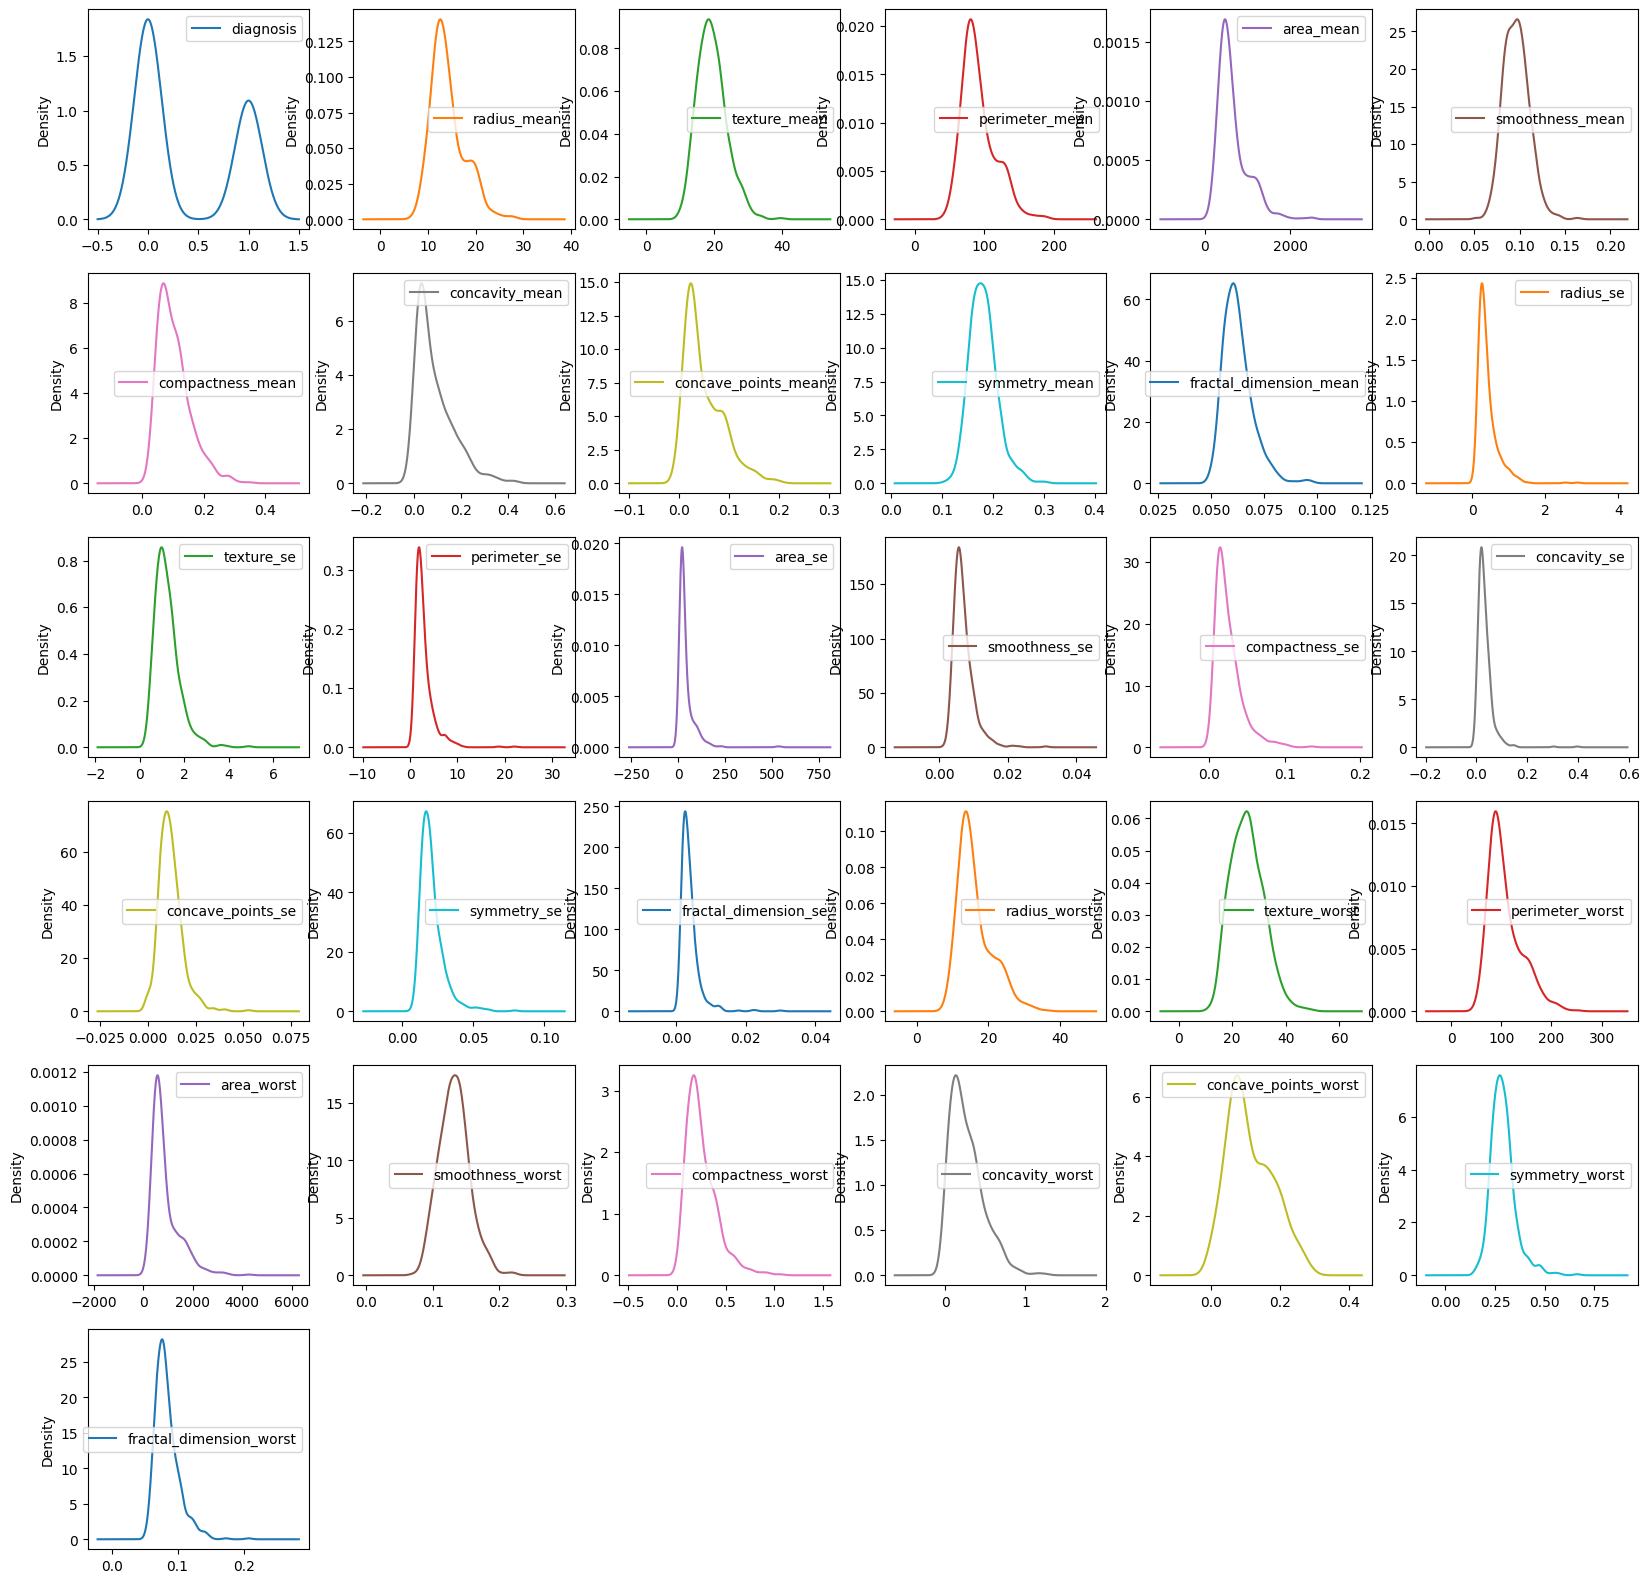

In [35]:
data.plot(kind='density', subplots=True, layout=(6, 6), sharex=False, figsize=(20, 20))
pyplot.show()

### Box and Whisker plots (by diagnosis)

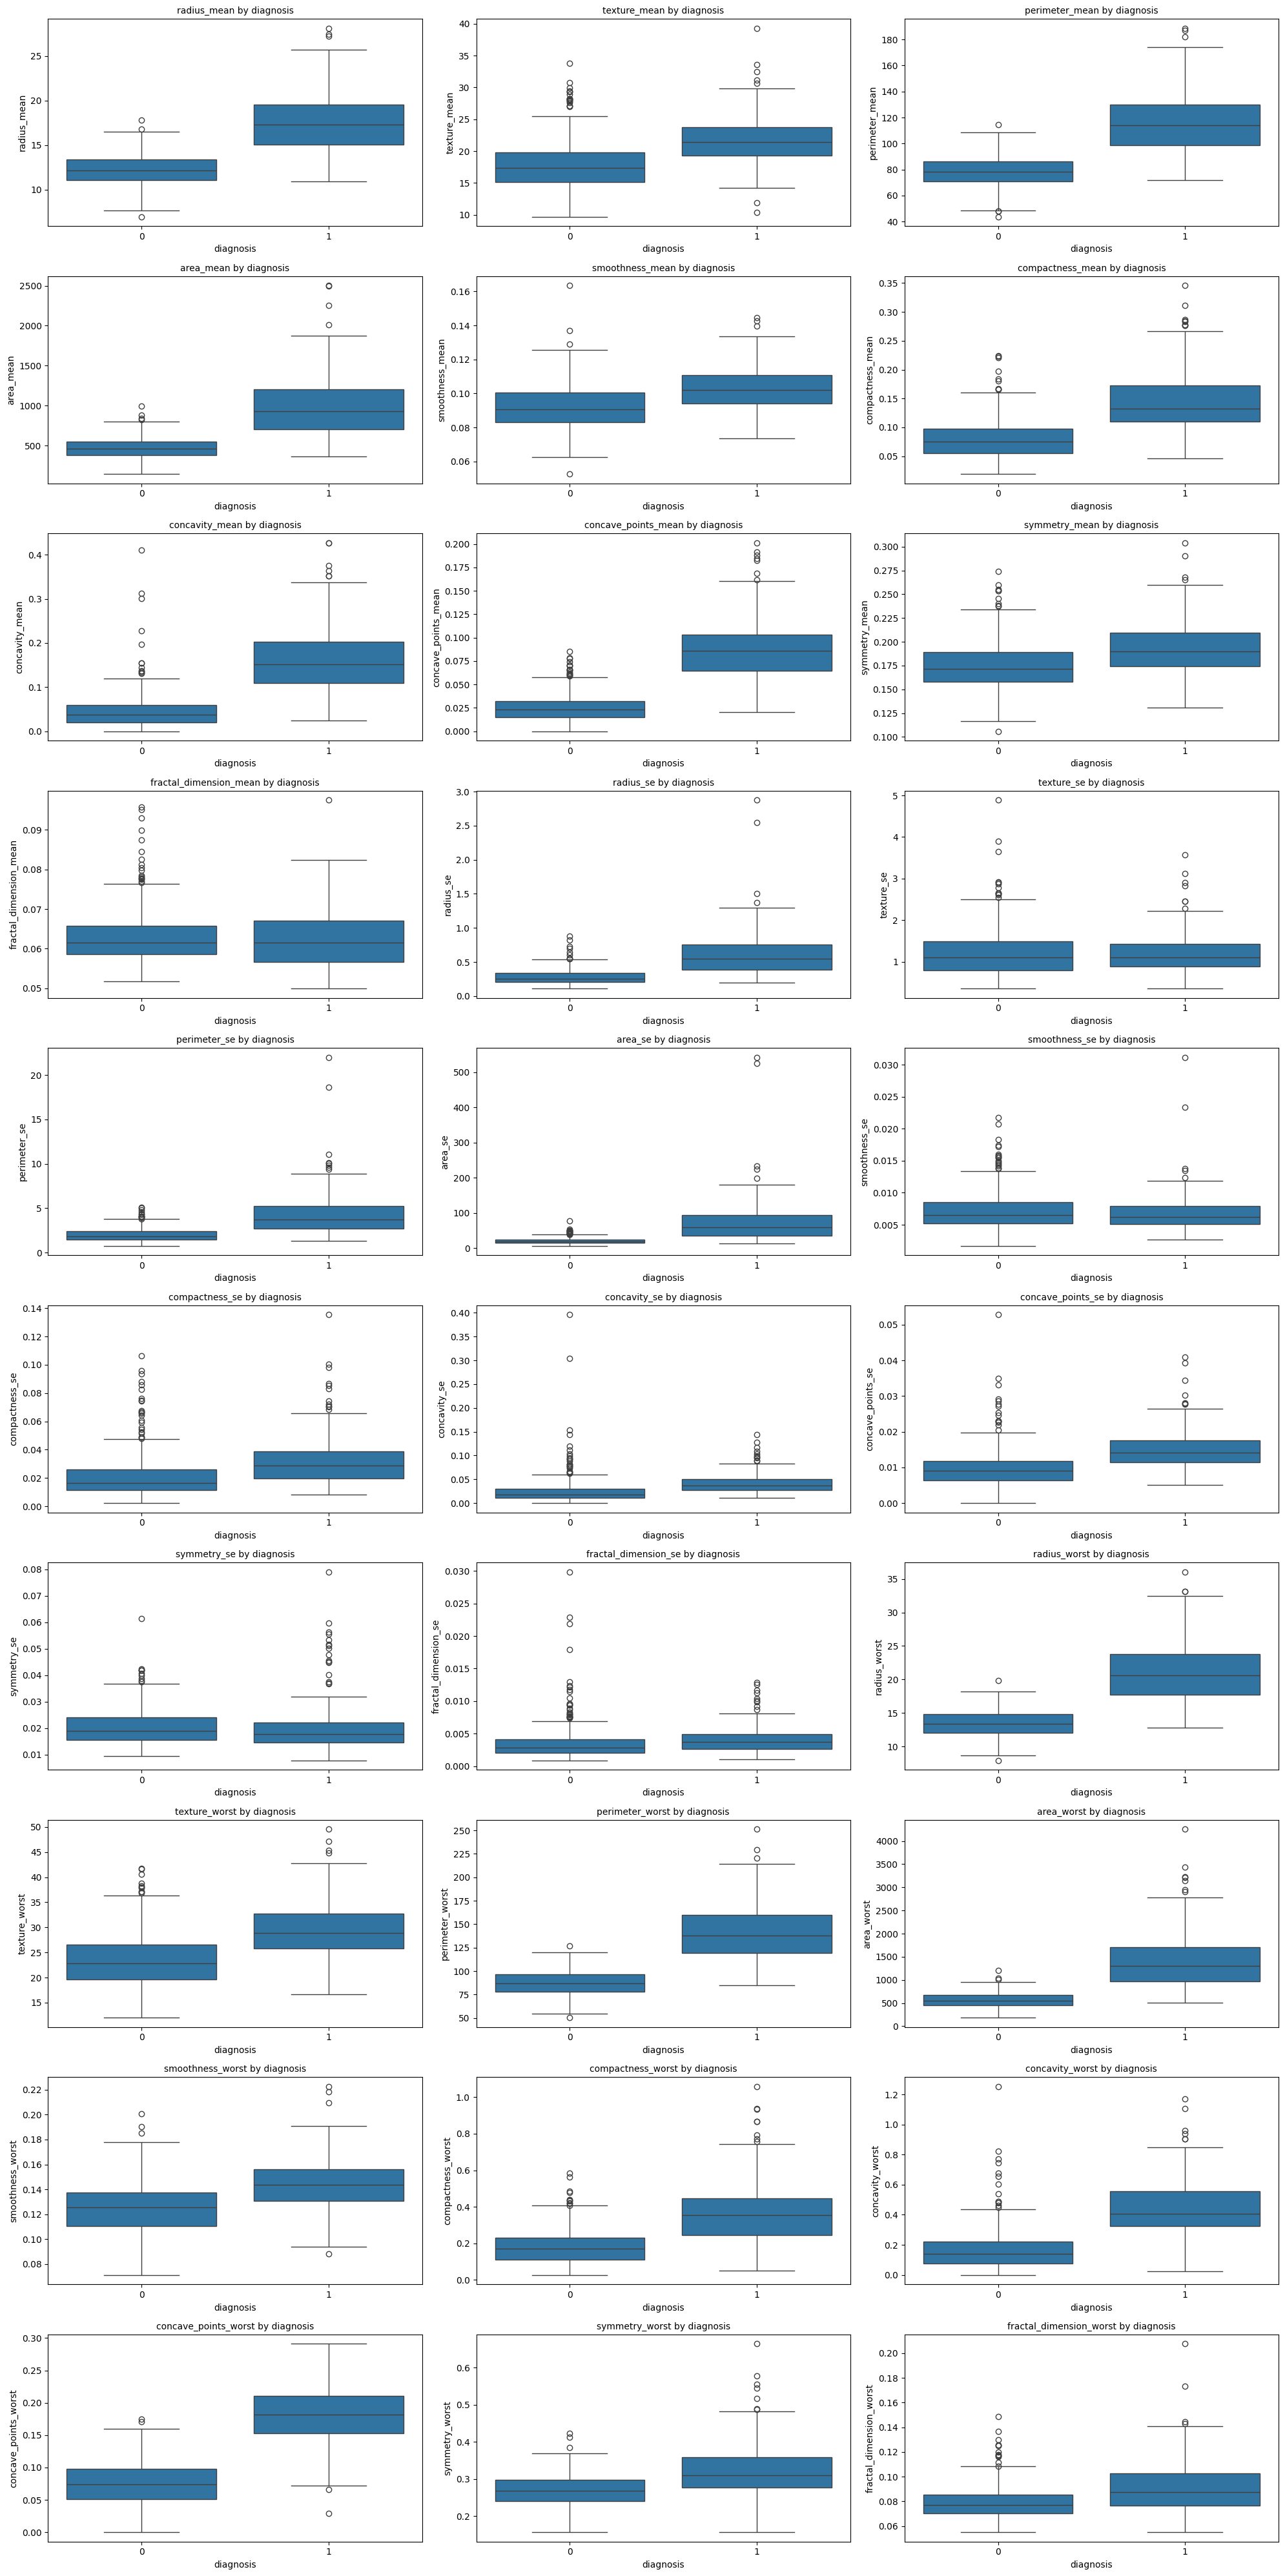

In [36]:
import seaborn as sns

features = data.columns.drop('diagnosis')

fig = pyplot.figure(figsize=(20, 40))
for i, feature in enumerate(features, 1):
    pyplot.subplot(10, 3, i)
    sns.boxplot(data=data, x='diagnosis', y=feature)
    pyplot.title(f'{feature} by diagnosis', fontsize=10)
pyplot.tight_layout()
pyplot.show()

### Correlation matrix plot

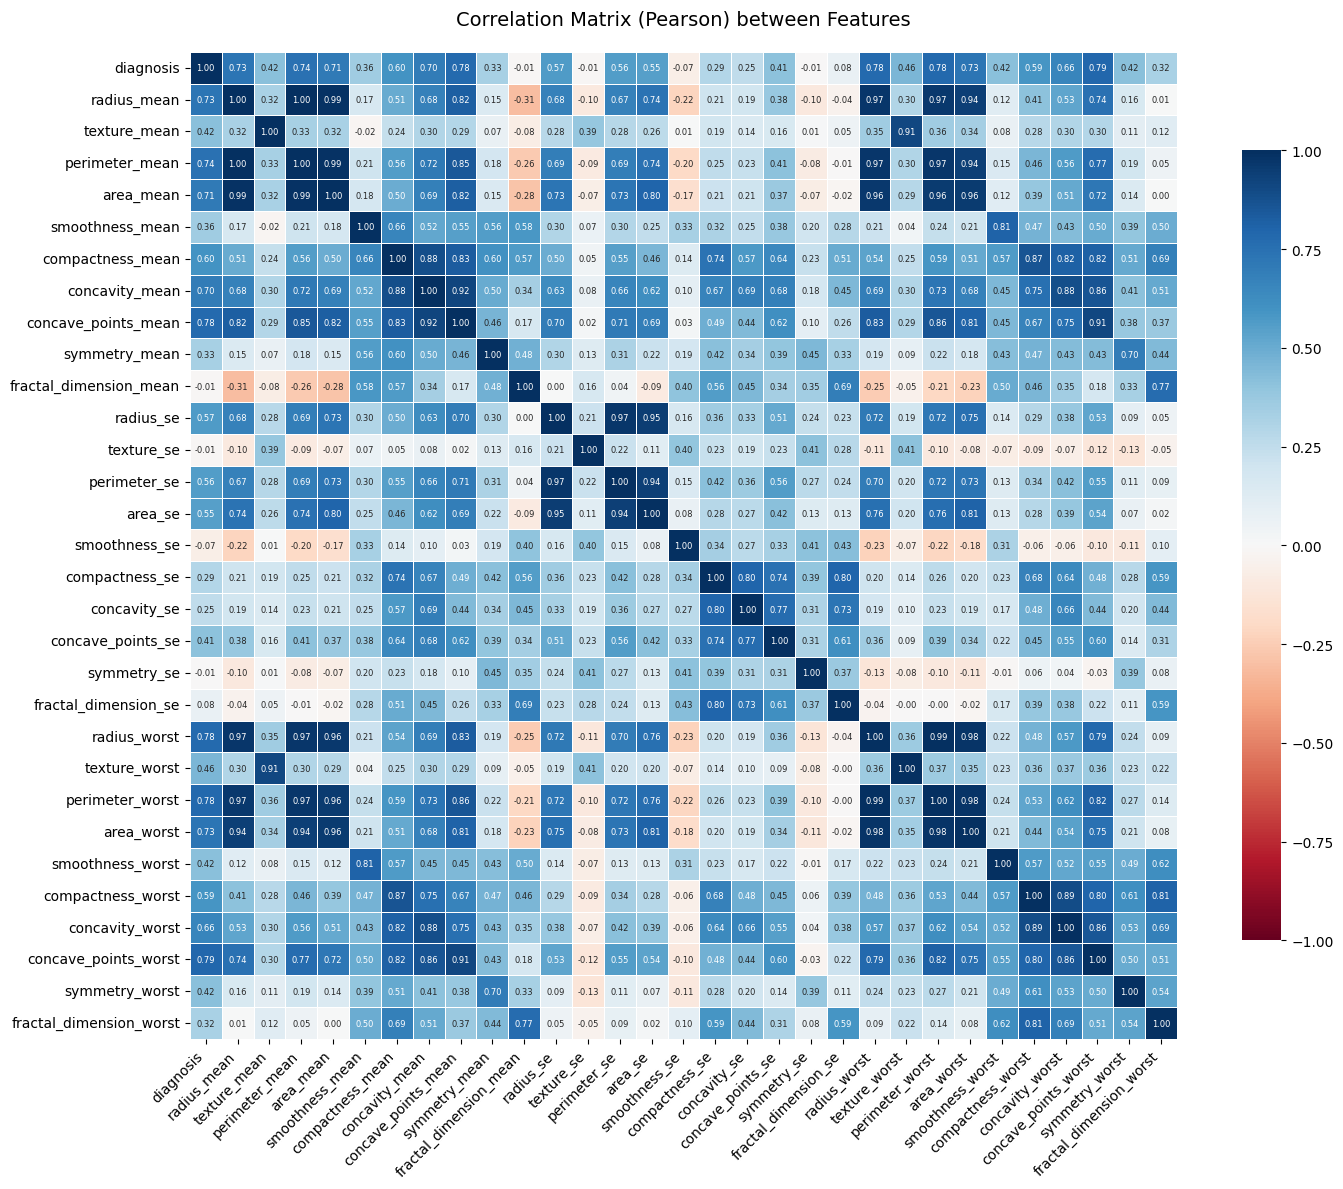

Highly correlated feature pairs (|r| > 0.95):
radius_mean - perimeter_mean: 1.0
radius_mean - area_mean: 0.99
radius_mean - radius_worst: 0.97
radius_mean - perimeter_worst: 0.97
perimeter_mean - area_mean: 0.99
perimeter_mean - radius_worst: 0.97
perimeter_mean - perimeter_worst: 0.97
area_mean - radius_worst: 0.96
area_mean - perimeter_worst: 0.96
area_mean - area_worst: 0.96
radius_se - perimeter_se: 0.97
radius_se - area_se: 0.95
radius_worst - perimeter_worst: 0.99
radius_worst - area_worst: 0.98
perimeter_worst - area_worst: 0.98


In [38]:
fig = pyplot.figure(figsize=(15, 12))

sns.heatmap(correlations,
            cmap='RdBu',
            vmin=-1,
            vmax=1,
            center=0,
            annot=True,
            fmt=".2f",
            square=True,
            linewidths=.5,
            cbar_kws={"shrink": .8},
            annot_kws={'size': 6})

pyplot.xticks(rotation=45, ha='right')
pyplot.yticks(rotation=0)
pyplot.title('Correlation Matrix (Pearson) between Features', pad=20, fontsize=14)
pyplot.tight_layout()
pyplot.show()

import numpy as np

high_corr = np.where(np.abs(correlations.values) > 0.95)
high_corr_pairs = [
    (correlations.columns[x], correlations.columns[y], round(correlations.iloc[x, y], 2))
    for x, y in zip(*high_corr) if x != y and x < y
]

print("Highly correlated feature pairs (|r| > 0.95):")
for pair in high_corr_pairs:
    print(f"{pair[0]} - {pair[1]}: {pair[2]}")

### Scatter plot matrix

With 30 features, a full scatter matrix would be too large to read, so I limited it to the 10 mean features and the target.

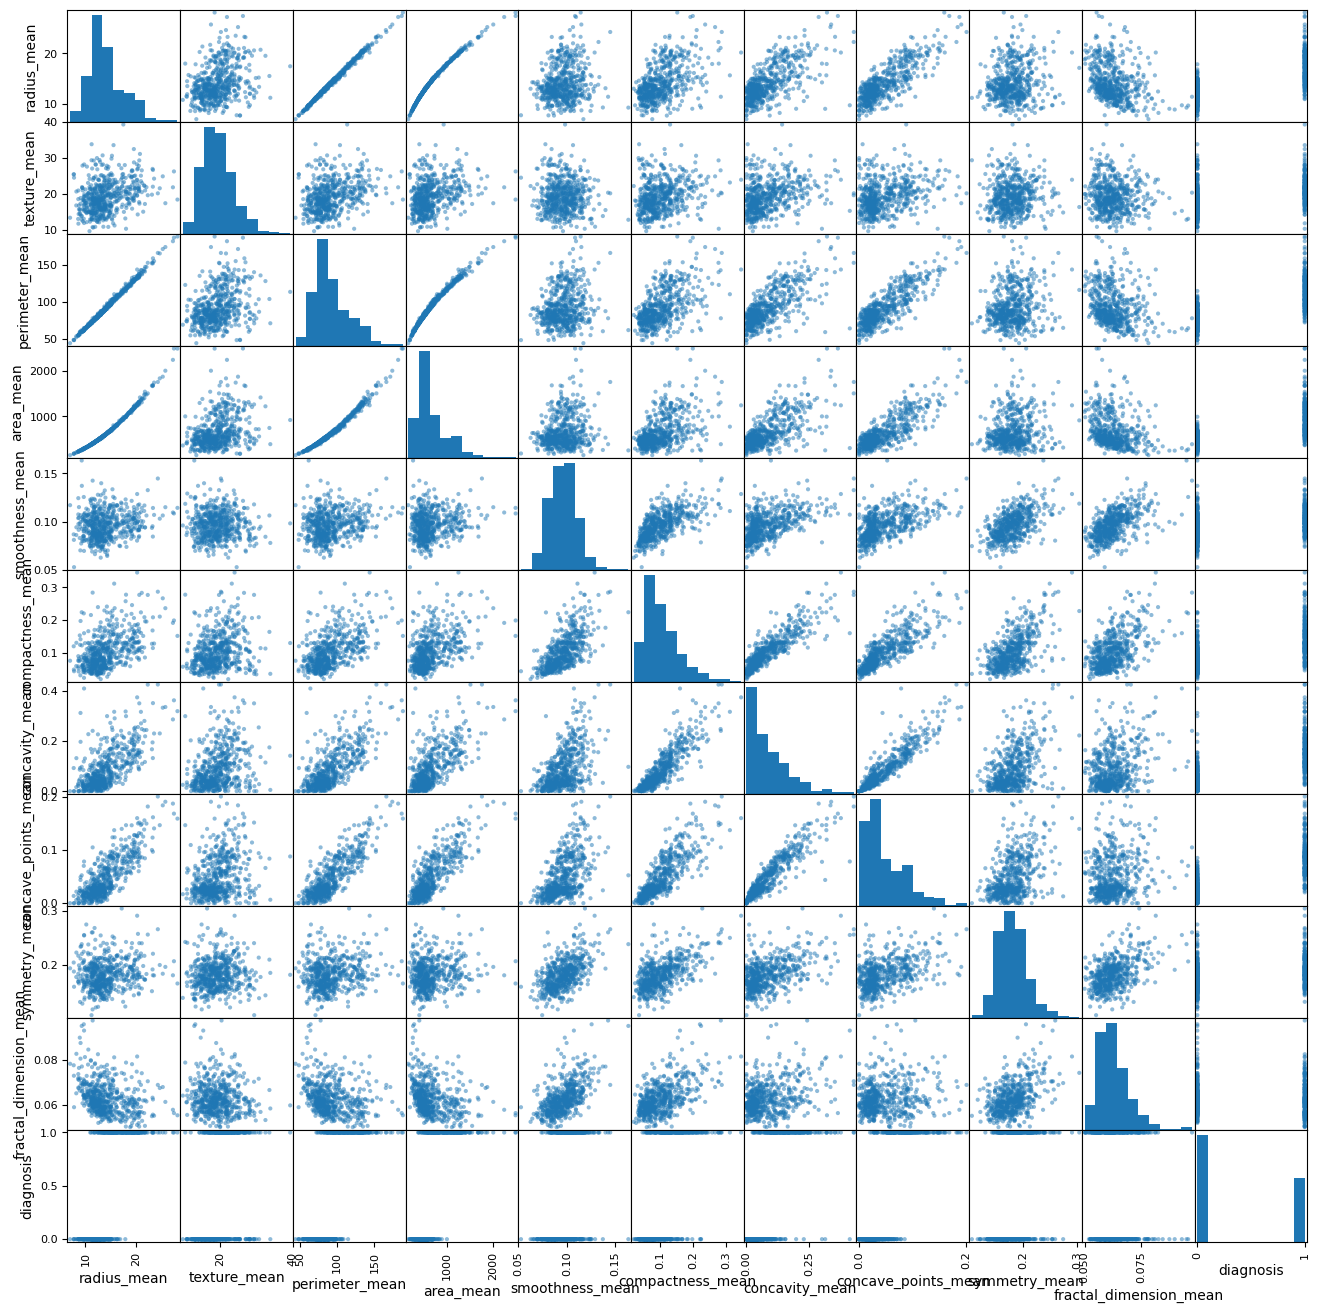

In [15]:
from pandas.plotting import scatter_matrix

mean_cols = [c for c in data.columns if c.endswith('_mean')] + ['diagnosis']
scatter_matrix(data[mean_cols], figsize=(16, 16))
pyplot.show()

## 4. Train/Test Split and Feature Scaling

Before doing any feature selection or model fitting, I splited the data into a training set and a held-out test set, and fit the scaler only on the training data. This avoids leaking information from the test set into preprocessing and as a result, overfitting.

Several of the algorithms I'll compare later (KNN, SVM, Logistic Regression) are sensitive to features being on very different scales, so standardizing is important for the downstream processing.

In [16]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from numpy import set_printoptions

array = data.values
X = array[:, 1:31]   # 30 numeric features
Y = array[:, 0]       # diagnosis

Training (80%), Test (20%)
X_train, X_test, Y_train, Y_test = train_test_split(
    X, Y, test_size=0.2, random_state=42, stratify=Y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

set_printoptions(precision=3)

print('Check standardization:')
print(f'Mean train original: {X_train.mean():.2f}')
print(f'Mean train scaled:   {X_train_scaled.mean():.2f} (should be near 0)')
print(f'Std train original:  {X_train.std():.2f}')
print(f'Std train scaled:    {X_train_scaled.std():.2f} (should be near 1)')

Check standardization:
Mean train original: 62.46
Mean train scaled:   -0.00 (should be near 0)
Std train original:  231.42
Std train scaled:    1.00 (should be near 1)


## 5. Feature Selection for ML

I looked at 2 feature selection techniques with scikit-learn, and used cross-validated accuracy to choose how many features to keep, instead of picking a fixed number:

1. Univariate Selection (`SelectKBest` with the ANOVA F-statistic, `f_classif`)
2. Recursive Feature Elimination (RFE)

Then I kept only the features that both methods agree are useful, and built a reduced and scaled feature set from that.

### 1. Univariate Selection (SelectKBest)

In [17]:
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score
import numpy as np

result_kbest = []

for k in range(5, 31):
    select = SelectKBest(score_func=f_classif, k=k)
    X_train_k = select.fit_transform(X_train_scaled, Y_train)

    model = LogisticRegression(solver='lbfgs', max_iter=5000)
    cv_score = cross_val_score(model, X_train_k, Y_train, cv=5, scoring='accuracy')
    result_kbest.append((k, np.mean(cv_score)))

best_k_kbest = max(result_kbest, key=lambda t: t[1])
for k, acc in result_kbest:
    print(f'k={k:2d}  -->  accuracy={acc:.4f}')
print(f'\nBest k for SelectKBest: {best_k_kbest[0]} (accuracy={best_k_kbest[1]:.4f})')

k= 5  -->  accuracy=0.9385
k= 6  -->  accuracy=0.9429
k= 7  -->  accuracy=0.9429
k= 8  -->  accuracy=0.9429
k= 9  -->  accuracy=0.9473
k=10  -->  accuracy=0.9516
k=11  -->  accuracy=0.9451
k=12  -->  accuracy=0.9429
k=13  -->  accuracy=0.9341
k=14  -->  accuracy=0.9363
k=15  -->  accuracy=0.9407
k=16  -->  accuracy=0.9670
k=17  -->  accuracy=0.9670
k=18  -->  accuracy=0.9714
k=19  -->  accuracy=0.9758
k=20  -->  accuracy=0.9736
k=21  -->  accuracy=0.9736
k=22  -->  accuracy=0.9736
k=23  -->  accuracy=0.9714
k=24  -->  accuracy=0.9736
k=25  -->  accuracy=0.9736
k=26  -->  accuracy=0.9736
k=27  -->  accuracy=0.9736
k=28  -->  accuracy=0.9736
k=29  -->  accuracy=0.9714
k=30  -->  accuracy=0.9714

Best k for SelectKBest: 19 (accuracy=0.9758)


In [18]:
select = SelectKBest(score_func=f_classif, k=best_k_kbest[0])
select.fit(X_train_scaled, Y_train)
selected_mask_kbest = select.get_support()
selected_features_kbest = np.array(feature_names)[selected_mask_kbest]

print("Selected features (SelectKBest):")
print(selected_features_kbest.tolist())

Selected features (SelectKBest):
['radius_mean', 'texture_mean', 'perimeter_mean', 'area_mean', 'compactness_mean', 'concavity_mean', 'concave_points_mean', 'radius_se', 'perimeter_se', 'area_se', 'radius_worst', 'texture_worst', 'perimeter_worst', 'area_worst', 'smoothness_worst', 'compactness_worst', 'concavity_worst', 'concave_points_worst', 'symmetry_worst']


### 2. Recursive Feature Elimination

In [19]:
from sklearn.feature_selection import RFE

result_rfe = []
model = LogisticRegression(solver='lbfgs', max_iter=5000)

for k in range(5, 31):
    rfe = RFE(estimator=model, n_features_to_select=k)
    X_train_rfe = rfe.fit_transform(X_train_scaled, Y_train)

    cv_scores = cross_val_score(model, X_train_rfe, Y_train, cv=5, scoring='accuracy')
    result_rfe.append((k, np.mean(cv_scores)))

best_k_rfe = max(result_rfe, key=lambda t: t[1])
for k, acc in result_rfe:
    print(f'k={k:2d}  -->  accuracy={acc:.4f}')
print(f'\nBest k for RFE: {best_k_rfe[0]} (accuracy={best_k_rfe[1]:.4f})')

k= 5  -->  accuracy=0.9604
k= 6  -->  accuracy=0.9692
k= 7  -->  accuracy=0.9626
k= 8  -->  accuracy=0.9626
k= 9  -->  accuracy=0.9626
k=10  -->  accuracy=0.9714
k=11  -->  accuracy=0.9714
k=12  -->  accuracy=0.9692
k=13  -->  accuracy=0.9714
k=14  -->  accuracy=0.9714
k=15  -->  accuracy=0.9714
k=16  -->  accuracy=0.9714
k=17  -->  accuracy=0.9758
k=18  -->  accuracy=0.9714
k=19  -->  accuracy=0.9736
k=20  -->  accuracy=0.9736
k=21  -->  accuracy=0.9758
k=22  -->  accuracy=0.9758
k=23  -->  accuracy=0.9758
k=24  -->  accuracy=0.9736
k=25  -->  accuracy=0.9758
k=26  -->  accuracy=0.9736
k=27  -->  accuracy=0.9714
k=28  -->  accuracy=0.9714
k=29  -->  accuracy=0.9714
k=30  -->  accuracy=0.9714

Best k for RFE: 17 (accuracy=0.9758)


In [20]:
rfe = RFE(estimator=LogisticRegression(solver='lbfgs', max_iter=5000), n_features_to_select=best_k_rfe[0])
rfe.fit(X_train_scaled, Y_train)
selected_mask_rfe = rfe.get_support()
selected_features_rfe = np.array(feature_names)[selected_mask_rfe]

print("Selected features (RFE):")
print(selected_features_rfe.tolist())

Selected features (RFE):
['radius_mean', 'texture_mean', 'area_mean', 'concavity_mean', 'concave_points_mean', 'radius_se', 'perimeter_se', 'area_se', 'compactness_se', 'radius_worst', 'texture_worst', 'perimeter_worst', 'area_worst', 'smoothness_worst', 'concavity_worst', 'concave_points_worst', 'symmetry_worst']


### Combine both methods

In [21]:
common_features = sorted(set(selected_features_kbest) & set(selected_features_rfe))
print(f'Number of common features: {len(common_features)}')
print('Common features:')
for f in common_features:
    print('-', f)

X_reduced = data[common_features].values
Y_reduced = data['diagnosis'].values

X_train_sel, X_test_sel, Y_train_sel, Y_test_sel = train_test_split(
    X_reduced, Y_reduced, test_size=0.2, random_state=42, stratify=Y_reduced
)

scaler_sel = StandardScaler()
X_train_scaled_sel = scaler_sel.fit_transform(X_train_sel)
X_test_scaled_sel = scaler_sel.transform(X_test_sel)

Number of common features: 16
Common features:
- area_mean
- area_se
- area_worst
- concave_points_mean
- concave_points_worst
- concavity_mean
- concavity_worst
- perimeter_se
- perimeter_worst
- radius_mean
- radius_se
- radius_worst
- smoothness_worst
- symmetry_worst
- texture_mean
- texture_worst


Although I did not used further here, since it makes the transformed features hard to interpret, Principal Component Analysis projects the 30 features onto a smaller number of uncorrelated components that explain most of the variance.

In [22]:
from sklearn.decomposition import PCA

pca = PCA(n_components=10)
fit = pca.fit(X_train_scaled)
print("Explained variance ratio (first 10 components):")
print(fit.explained_variance_ratio_)
print(f"\nTotal variance explained by 10 components: {fit.explained_variance_ratio_.sum():.3f}")

Explained variance ratio (first 10 components):
[0.446 0.185 0.096 0.066 0.056 0.04  0.022 0.016 0.013 0.012]

Total variance explained by 10 components: 0.952


## 6. Evaluating the Performance with Resampling

Rather than relying on a single train/test split, I used k-fold cross-validation with a few different numbers of folds, and compared the full (30-feature) scaled dataset against the reduced (feature-selected) scaled dataset, to see whether feature selection is actually working.

In [23]:
%%time
from sklearn.model_selection import KFold

num_folds = [3, 5, 10]
seed = 2

result_kfold_full = []
for num in num_folds:
    kfold = KFold(n_splits=num, random_state=seed, shuffle=True)
    model = LogisticRegression(solver='lbfgs', max_iter=5000)
    results = cross_val_score(model, X_train_scaled, Y_train, cv=kfold)
    result_kfold_full.append(
        f"Splits: {num} -> Accuracy: {results.mean() * 100:.2f}% (+/- {results.std() * 100:.2f}%)"
    )

print("Full feature set:")
for line in result_kfold_full:
    print(line)

Full feature set:
Splits: 3 -> Accuracy: 96.92% (+/- 0.82%)
Splits: 5 -> Accuracy: 96.70% (+/- 1.55%)
Splits: 10 -> Accuracy: 97.36% (+/- 2.73%)
CPU times: user 302 ms, sys: 3.01 ms, total: 305 ms
Wall time: 161 ms


In [24]:
%%time
result_kfold_selected = []
for num in num_folds:
    kfold = KFold(n_splits=num, random_state=seed, shuffle=True)
    model = LogisticRegression(solver='lbfgs', max_iter=5000)
    results = cross_val_score(model, X_train_scaled_sel, Y_train_sel, cv=kfold)
    result_kfold_selected.append(
        f"Splits: {num} -> Accuracy: {results.mean() * 100:.2f}% (+/- {results.std() * 100:.2f}%)"
    )

print("Reduced (feature-selected) set:")
for line in result_kfold_selected:
    print(line)

Reduced (feature-selected) set:
Splits: 3 -> Accuracy: 96.70% (+/- 0.01%)
Splits: 5 -> Accuracy: 96.92% (+/- 0.44%)
Splits: 10 -> Accuracy: 97.36% (+/- 1.64%)
CPU times: user 220 ms, sys: 13 µs, total: 220 ms
Wall time: 115 ms


Comparing the two blocks above shows whether keeping only the common features costs us any cross-validated accuracy relative to using all 30 - if the numbers are close, the smaller, more interpretable feature set is a reasonable trade-off.

## 7. Comparing and Tuning Machine Learning Algorithms

I compared 5 classification algorithms on the full scaled training set, tuning each one's hyperparameters with `GridSearchCV` (5-fold CV) instead of using default settings, then evaluate every tuned model once on the held-out test set with a full set of metrics:

* Accuracy
* F1 score
* Matthews Correlation Coefficient
* AUC (Area under the ROC curve)
* Confusion matrix
* Classification report
* ROC curve

Algorithms compared:
* Logistic Regression
* k-Nearest Neighbors
* Support Vector Machine
* Gaussian Naive Bayes
* Classification and Regression Trees

In [25]:
from sklearn.model_selection import GridSearchCV
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    accuracy_score, confusion_matrix, classification_report,
    roc_curve, auc, matthews_corrcoef, f1_score
)

models = {
    "Logistic Regression": {
        'model': LogisticRegression(max_iter=5000),
        'params': [
            {'solver': ['liblinear'], 'penalty': ['l1', 'l2'], 'C': [0.001, 0.01, 0.1, 1, 10, 100]},
            {'solver': ['lbfgs'], 'penalty': ['l2'], 'C': [0.001, 0.01, 0.1, 1, 10, 100]}
        ]
    },
    "K-Nearest Neighbors": {
        'model': KNeighborsClassifier(),
        'params': {
            'n_neighbors': [3, 5, 7, 9, 11],
            'weights': ['uniform', 'distance'],
            'metric': ['euclidean', 'manhattan']
        }
    },
    "Support Vector Machine": {
        'model': SVC(probability=True),
        'params': {
            'C': [0.1, 1, 10],
            'kernel': ['linear', 'rbf', 'poly'],
            'gamma': ['scale', 'auto']
        }
    },
    "Gaussian Naive Bayes": {
        'model': GaussianNB(),
        'params': {}
    },
    "CART": {
        'model': DecisionTreeClassifier(random_state=7),
        'params': {
            'max_depth': [None, 5, 10, 20],
            'min_samples_split': [2, 5, 10],
            'criterion': ['gini', 'entropy']
        }
    }
}


Optimizing Logistic Regression...
Best parameters: {'C': 0.1, 'penalty': 'l2', 'solver': 'liblinear'}
Accuracy: 0.9825  |  AUC: 0.9977  |  F1: 0.9756  |  MCC: 0.9626
Classification report:
              precision    recall  f1-score   support

         0.0       0.97      1.00      0.99        72
         1.0       1.00      0.95      0.98        42

    accuracy                           0.98       114
   macro avg       0.99      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114



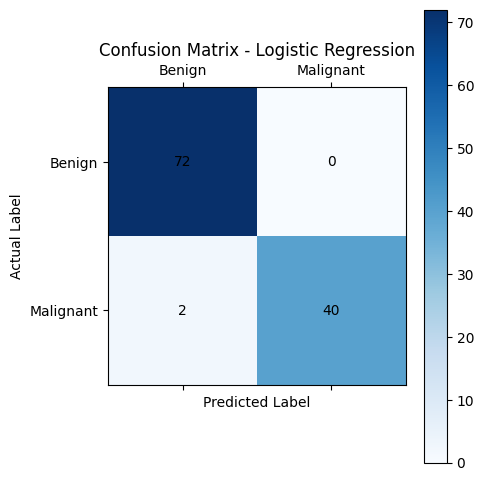

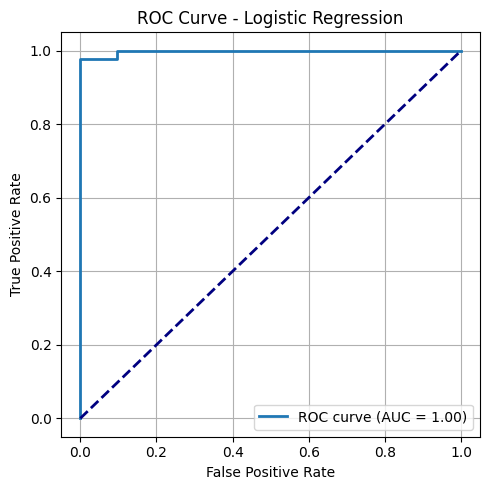


Optimizing K-Nearest Neighbors...
Best parameters: {'metric': 'euclidean', 'n_neighbors': 3, 'weights': 'uniform'}
Accuracy: 0.9386  |  AUC: 0.9825  |  F1: 0.9114  |  MCC: 0.8688
Classification report:
              precision    recall  f1-score   support

         0.0       0.92      0.99      0.95        72
         1.0       0.97      0.86      0.91        42

    accuracy                           0.94       114
   macro avg       0.95      0.92      0.93       114
weighted avg       0.94      0.94      0.94       114



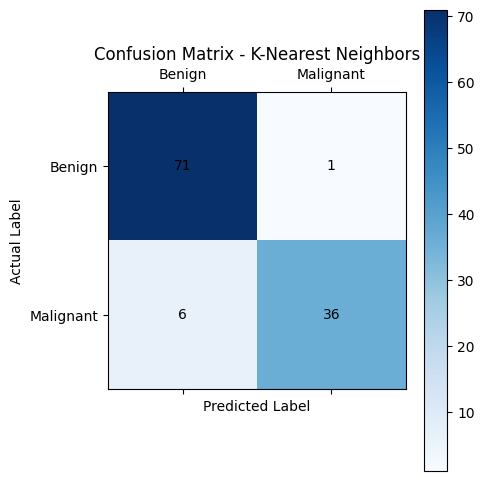

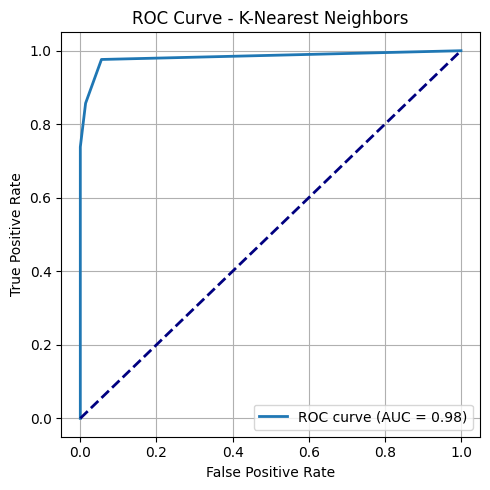


Optimizing Support Vector Machine...
Best parameters: {'C': 1, 'gamma': 'scale', 'kernel': 'rbf'}
Accuracy: 0.9737  |  AUC: 0.9947  |  F1: 0.9630  |  MCC: 0.9442
Classification report:
              precision    recall  f1-score   support

         0.0       0.96      1.00      0.98        72
         1.0       1.00      0.93      0.96        42

    accuracy                           0.97       114
   macro avg       0.98      0.96      0.97       114
weighted avg       0.97      0.97      0.97       114



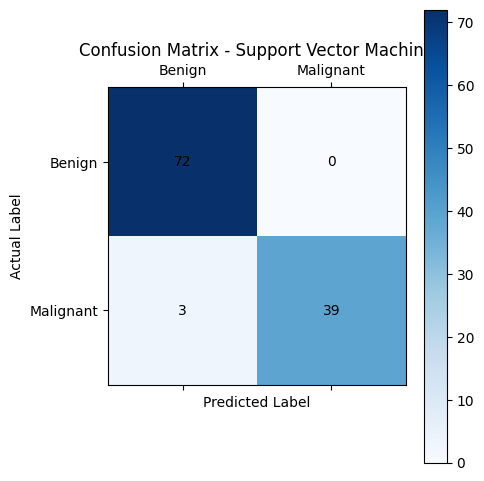

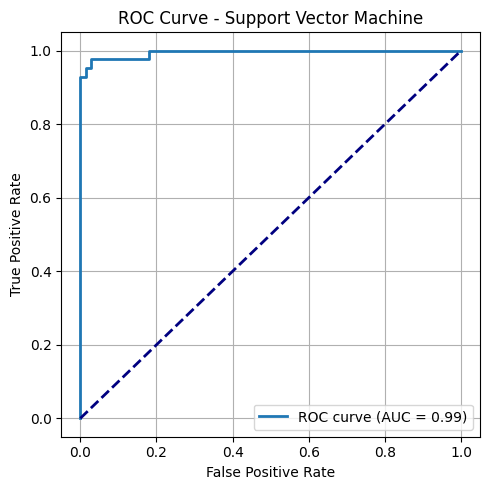


Optimizing Gaussian Naive Bayes...
Accuracy: 0.9211  |  AUC: 0.9891  |  F1: 0.8889  |  MCC: 0.8292
Classification report:
              precision    recall  f1-score   support

         0.0       0.92      0.96      0.94        72
         1.0       0.92      0.86      0.89        42

    accuracy                           0.92       114
   macro avg       0.92      0.91      0.91       114
weighted avg       0.92      0.92      0.92       114



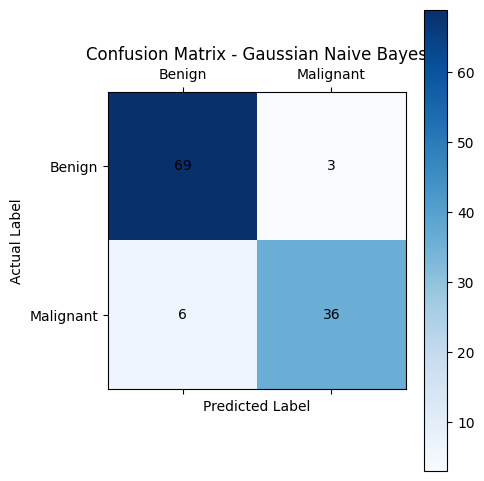

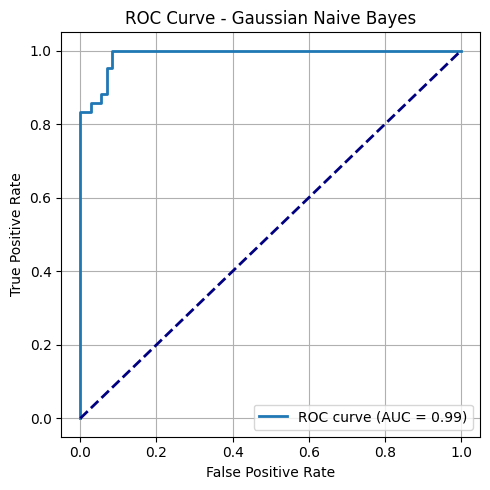


Optimizing CART...
Best parameters: {'criterion': 'entropy', 'max_depth': None, 'min_samples_split': 5}
Accuracy: 0.9561  |  AUC: 0.9396  |  F1: 0.9367  |  MCC: 0.9076
Classification report:
              precision    recall  f1-score   support

         0.0       0.94      1.00      0.97        72
         1.0       1.00      0.88      0.94        42

    accuracy                           0.96       114
   macro avg       0.97      0.94      0.95       114
weighted avg       0.96      0.96      0.96       114



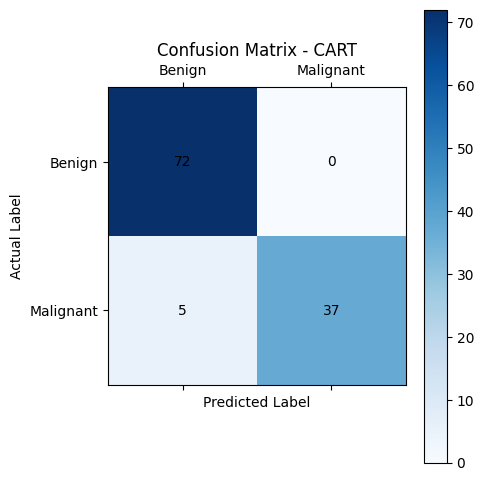

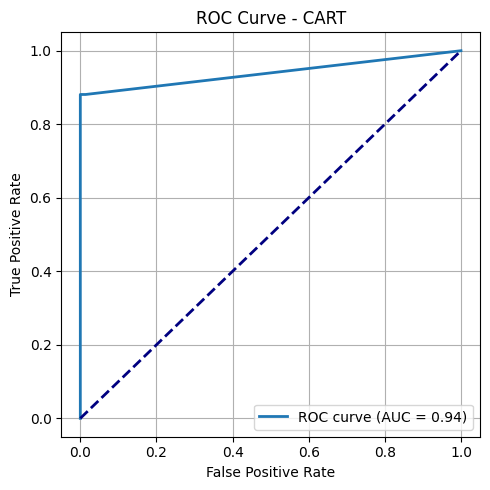

CPU times: user 3.2 s, sys: 75.9 ms, total: 3.27 s
Wall time: 18 s


In [26]:
%%time
results = {}
fitted_models = {}

for name, config in models.items():
    print(f"\nOptimizing {name}...")

    if config['params']:
        grid_search = GridSearchCV(
            estimator=config['model'],
            param_grid=config['params'],
            cv=5,
            scoring='accuracy',
            n_jobs=-1
        )
        grid_search.fit(X_train_scaled, Y_train)
        best_model = grid_search.best_estimator_
        print(f"Best parameters: {grid_search.best_params_}")
    else:
        best_model = config['model']
        best_model.fit(X_train_scaled, Y_train)

    fitted_models[name] = best_model

    y_pred = best_model.predict(X_test_scaled)
    y_probs = best_model.predict_proba(X_test_scaled)[:, 1]

    acc = accuracy_score(Y_test, y_pred)
    mcc = matthews_corrcoef(Y_test, y_pred)
    f1 = f1_score(Y_test, y_pred)
    cm = confusion_matrix(Y_test, y_pred)
    cr = classification_report(Y_test, y_pred)
    fpr, tpr, _ = roc_curve(Y_test, y_probs)
    roc_auc = auc(fpr, tpr)

    results[name] = {'Accuracy': acc, 'F1 Score': f1, 'MCC': mcc, 'AUC': roc_auc}

    print(f"Accuracy: {acc:.4f}  |  AUC: {roc_auc:.4f}  |  F1: {f1:.4f}  |  MCC: {mcc:.4f}")
    print("Classification report:")
    print(cr)

    # Confusion matrix plot
    fig_cm, ax = pyplot.subplots(figsize=(5, 5))
    cax = ax.matshow(cm, cmap='Blues')
    fig_cm.colorbar(cax)
    ax.set_xticks([0, 1]); ax.set_xticklabels(['Benign', 'Malignant'])
    ax.set_yticks([0, 1]); ax.set_yticklabels(['Benign', 'Malignant'])
    pyplot.title(f'Confusion Matrix - {name}')
    pyplot.ylabel('Actual Label')
    pyplot.xlabel('Predicted Label')
    for (i, j), val in np.ndenumerate(cm):
        ax.text(j, i, f'{val}', ha='center', va='center', color='black')
    pyplot.tight_layout()
    pyplot.show()

    # ROC curve plot
    pyplot.figure(figsize=(5, 5))
    pyplot.plot(fpr, tpr, lw=2, label=f'ROC curve (AUC = {roc_auc:.2f})')
    pyplot.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
    pyplot.xlabel('False Positive Rate')
    pyplot.ylabel('True Positive Rate')
    pyplot.title(f'ROC Curve - {name}')
    pyplot.legend(loc="lower right")
    pyplot.grid()
    pyplot.tight_layout()
    pyplot.show()

### Boxplot comparison of cross-validated accuracy (default hyperparameters)

Logistic Regression: 0.9780 (0.0196)
K-Nearest Neighbors: 0.9626 (0.0199)
Support Vector Machine: 0.9737 (0.0190)
Gaussian Naive Bayes: 0.9406 (0.0223)
CART: 0.9165 (0.0349)


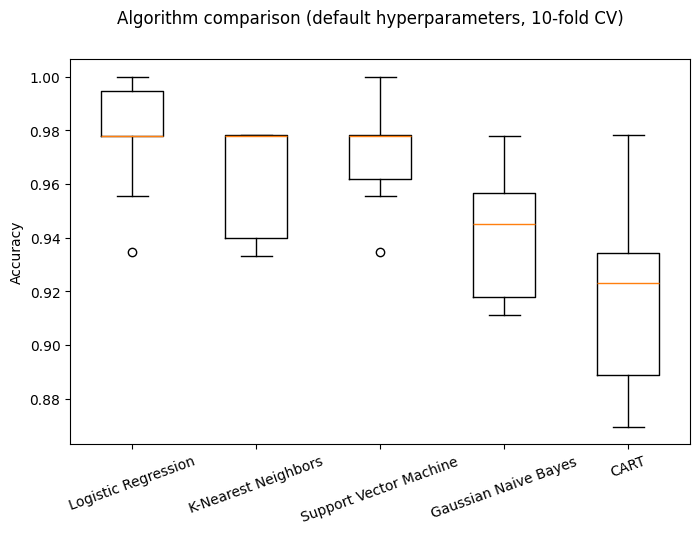

CPU times: user 933 ms, sys: 8.91 ms, total: 942 ms
Wall time: 766 ms


In [39]:
%%time
# For a quick look at the algorithms with default settings
# (separate from the tuned models above), a 10-fold CV boxplot comparison:
cv_results = []
cv_names = []
for name, config in models.items():
    kfold = KFold(n_splits=10, random_state=7, shuffle=True)
    scores = cross_val_score(config['model'], X_train_scaled, Y_train, cv=kfold, scoring='accuracy')
    cv_results.append(scores)
    cv_names.append(name)
    print(f"{name}: {scores.mean():.4f} ({scores.std():.4f})")

fig = pyplot.figure(figsize=(8, 5))
fig.suptitle('Algorithm comparison (default hyperparameters, 10-fold CV)')
ax = fig.add_subplot(111)
pyplot.boxplot(cv_results)
ax.set_xticklabels(cv_names, rotation=20)
pyplot.ylabel('Accuracy')
pyplot.show()

## 8. Summary of Results

In [40]:
result_df = pd.DataFrame.from_dict(results, orient='index')
result_df = result_df.sort_values(by='Accuracy', ascending=False)
result_df

,Accuracy,F1 Score,MCC,AUC
Logistic Regression,0.982456,0.975610,0.962622,0.997685
Support Vector Machine,0.973684,0.962963,0.944155,0.994709
CART,0.956140,0.936709,0.907605,0.939649
K-Nearest Neighbors,0.938596,0.911392,0.868766,0.982474
Gaussian Naive Bayes,0.921053,0.888889,0.829162,0.989087
